Goal: Add noises to speech audio files based on a CSV file containing word, noise, and audio onset information. The script will read the CSV file, load the corresponding audio files, and apply the specified noise at the given onset times. The processed audio files will be saved in a designated output directory.

- Author: Xiang Zhang, Zhengjia Wang
- Maintainer: Zhengjia Wang
- Created: 2024-06-13
- Last Change: 2026-07-17: 
  - Fixed multiple bugs on audio processing and file handling
  - Clean up the code and added to Wiki

Core:

- Ingest denoised speech mp4 files
- Normalizes the audio files to a standard volume level during speech segments (according to speech onset and offset time)
- Generate noise based on the spectrum of all speeches from the inputs, normalized to the same volume level as the speech segments
- Blend the generated noise with the normalized speech audio with -4dB SNR (Signal-to-Noise Ratio) 
- Save the blended results to designated output directories

Environment:

- MacOS
- ffmpeg (installed via HomeBrew)
- Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]
- numpy: 2.4.5
- pydub: 0.25.1


In [108]:
# Config pip packages
%pip install -q pydub

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os.chdir("/Users/dipterix/PennNeurosurgery Dropbox/Dipterix W/BeauchampLabAtPenn/LabWiki/pages/Beauchamp/Data_Processing/Noisy Speech Generator/")

In [ ]:

import os

# VS Code's Jupyter launches the kernel with its working directory set to the
# notebook's own folder (the `jupyter.notebookFileRoot` setting defaults to
# "${fileDirname}"), so the current working directory IS the notebook directory.
notebook_dir = os.getcwd()


## Setup

Create a `"word_noise_aud_onset.csv"` file under the working directory with the following table:

| Filename | Word | Speaker | ClipStart | AudStart | AudEnd | ClipEnd |
|----------|------|---------|-----------|----------|--------|---------|
|AFOOT_AMANDA | afoot |	Amanda |0 |0.627 | 1.434 | 1.941 |
|AFOOT_LIN | afoot | Lin | 0 | 0.668 | 1.293 | 1.941 |
| ... | ... | ... | ... | ... | ... | ... |

The file names should match the audio files in the `denoised_file` directory. The `AudStart` and `AudEnd` columns indicate the start and end times of the audio segment to be extracted from each file. The video file extension should be `.mp4`. If the file is not found, the code will look for a file with `_a` appended to the base filename (e.g., `AFOOT_AMANDA_a.mp4`).

In [109]:
# Working directory holding the data
work_path = os.path.join(notebook_dir, 'data')
csv_file = 'word_noise_aud_onset.csv'

# Directory containing the audio files
# The input folder is called "denoised_file" because the original audio files,
# especiall some old stimuli files may have some background noises, such as
# line noises or mic noises. Please remove the noises from the original audio 
# files before running this code.
audio_dir = 'denoised_file'

# 2 seconds of audio duration for processing
audio_duration = 2.1


# verbosive level
verbose = False

# Dry-run mode (set to True to skip actual processing)
dry_run = True

# Quick check
if not os.path.exists(work_path):
    raise FileNotFoundError(f"Working directory '{work_path}' does not exist.")

In [110]:
# Register functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess, tempfile, os
from scipy.io import wavfile
from scipy.signal import welch
from scipy.fftpack import fft, ifft
from pydub import AudioSegment
from pydub.utils import which

FFMPEG = which("ffmpeg")   # same binary pydub uses; None if not on PATH

if FFMPEG is None:
    raise RuntimeError("ffmpeg not found. Please install ffmpeg and ensure it's on your PATH.")

def mux_audio_with_video(video_path, audio_segment, out_path):
    """Replace the audio track of `video_path` with `audio_segment`, keep video as-is."""
    # 1. Dump the processed AudioSegment to a temp WAV (lossless intermediate)
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        tmp_wav = tmp.name
    audio_segment.export(tmp_wav, format="wav")

    try:
        cmd = [
            FFMPEG, "-y",
            "-i", video_path,      # input 0: original video (+ its audio)
            "-i", tmp_wav,         # input 1: your new audio
            "-map", "0:v:0",       # take video from input 0
            "-map", "1:a:0",       # take audio from input 1
            "-c:v", "copy",        # DON'T re-encode video -> fast, lossless, in-sync
            "-c:a", "aac", "-b:a", "192k",
            "-shortest",
            out_path,
        ]
        subprocess.run(cmd, check=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
    finally:
        os.remove(tmp_wav)

# Function to find the path from filename
def find_mp4_path(base_filename, modality = None):
    # Determine the full file name
    if modality is None:
        full_filename = os.path.join(work_path, audio_dir, base_filename + '.mp4')
        if not os.path.exists(full_filename):
            full_filename = os.path.join(work_path, audio_dir, base_filename + '_a.mp4')
    elif modality == 'a':
        full_filename = os.path.join(work_path, audio_dir, base_filename + '_a.mp4')
    elif modality == 'v':
        full_filename = os.path.join(work_path, audio_dir, base_filename + '.mp4')
    else:
        raise ValueError(f"Invalid modality: {modality}. Use 'a' for audio or 'v' for video, or `None` for default.")
    # Check if the file exists before processing
    if os.path.exists(full_filename):
        return full_filename
    else:
        if verbose:
            print(f"File not found: {full_filename}")
        return None


# Function to extract audio data from MP4 file
def extract_audio(file_path):
    audio = AudioSegment.from_file(file_path)
    audio = audio.set_channels(1)  # Convert to mono if stereo
    samples = np.array(audio.get_array_of_samples())
    return samples, audio.frame_rate

# Function to conform audio length to a target duration
def conform_audio_length(samples, sample_rate, target_duration, start_time=0):
    target_length = int(sample_rate * target_duration)  # +1 to ensure we have enough samples
    start_time_samples = int(sample_rate * start_time)
    samples = samples[start_time_samples:]  # Start from the specified start time
    current_length = len(samples)
    
    if current_length < target_length:
        # Pad with zeros if shorter
        padding = np.zeros(target_length - current_length, dtype=samples.dtype)
        samples = np.concatenate((samples, padding))
    elif current_length > target_length:
        # Truncate if longer
        samples = samples[:target_length]
    
    return samples

# Function to compute FFT
def compute_fft(samples):
    return fft(samples)

# Function to extract the speech envelope from the audio file
def extract_speech_envelope(audio_file, start_time, end_time):
    # Load the audio file
    audio = AudioSegment.from_file(audio_file)
    
    # Convert start and end times to milliseconds
    start_time_ms = start_time * 1000
    end_time_ms = end_time * 1000
    
    # Extract the speech envelope
    speech_envelope = audio[start_time_ms:end_time_ms]
    
    # Convert to numpy array and sample rate
    sample_rate = audio.frame_rate
    speech_envelope = np.array(speech_envelope.get_array_of_samples())
    
    return speech_envelope, sample_rate

# Function to plot the Welch periodogram
def plot_welch_periodogram(data, sample_rate, ax):
    f, Pxx = welch(data, fs=sample_rate, nperseg=1024)
    ax.semilogy(f, Pxx)

# Function to compute the Welch periodogram
def compute_welch_periodogram(data, sample_rate):
    f, Pxx = welch(data, fs=sample_rate, nperseg=1024)
    return f, Pxx

# Generate a 2-second noise audio based on the average periodogram
def generate_noise_from_periodogram(mean_periodogram, frequencies, sample_rate, duration=2):
    num_samples = int(sample_rate * duration)
    
    # Output one-sided frequency bins
    out_freqs = np.fft.rfftfreq(num_samples, 1.0 / sample_rate)
    
    # Interpolate PSD to match output frequency resolution
    psd_interp = np.interp(out_freqs, frequencies, mean_periodogram)
    
    # Convert PSD (V^2/Hz) to FFT amplitude: |X[k]| = sqrt(Pxx[k] * fs * N / 2)
    amplitude = np.sqrt(psd_interp * sample_rate * num_samples / 2.0)
    
    # Random phase
    random_phase = np.exp(1j * np.random.uniform(0, 2 * np.pi, len(amplitude)))
    random_phase[0] = 1.0   # DC must be real
    if num_samples % 2 == 0:
        random_phase[-1] = 1.0  # Nyquist must be real
    
    # irfft handles conjugate symmetry automatically
    noise = np.fft.irfft(amplitude * random_phase, n=num_samples)
    
    # Normalize
    noise = (noise / np.max(np.abs(noise))) * 32767
    return noise.astype(np.int16)


def normalize_sound(wav, tp_range = None):
    wav_f = wav.astype(np.float32)
    mag2 = wav_f * wav_f
    if tp_range is not None:
        tp_range = np.round(tp_range).astype(np.int64)
        mag2 = mag2[tp_range[0]:tp_range[1]]
    # max_magnitude = np.sqrt(np.max( mag2 ))
    mean_magnitude = np.sqrt( np.mean( mag2 ) )
    if mean_magnitude == 0:
        mean_magnitude = 1.0  # Avoid division by zero; if mean magnitude is zero, keep the waveform unchanged
    wav_norm = (wav_f / mean_magnitude * 2048.)
    wav_norm[wav_norm > 32767] = 32767
    wav_norm[wav_norm < -32767] = -32767
    return wav_norm.astype(np.int16)

def get_sound_level(wav, tp_range = None):
    wav_f = wav.astype(np.float32)
    mag2 = wav_f * wav_f
    if tp_range is not None:
        tp_range = np.round(tp_range).astype(np.int64)
        mag2 = mag2[tp_range[0]:tp_range[1]]
    # max_magnitude = np.sqrt(np.max( mag2 ))
    mean_magnitude = np.sqrt( np.mean( mag2 ) )
    return mean_magnitude

def generate_audioclip(x, sample_rate, normalize = False):
    if normalize:
        x = normalize_sound(x)
    
    # Create an AudioSegment from the numpy array
    audio_segment = AudioSegment(
        x.tobytes(),
        frame_rate=sample_rate,
        sample_width=x.dtype.itemsize,
        channels=1
    )
    return audio_segment

In [111]:
# Read the CSV file
df = pd.read_csv(os.path.join(work_path, csv_file))
df

,Filename,Word,Speaker,ClipStart,AudStart,AudEnd,ClipEnd
0,AFOOT_AMANDA,afoot,Amanda,0,0.627,1.434,1.941
1,AFOOT_LIN,afoot,Lin,0,0.668,1.293,1.941
2,ALONG_CAMERON,along,Cameron,0,1.105,1.649,1.941
3,ALONG_DANIELLE,along,Danielle,0,0.621,1.380,1.941
4,ALONG_LIN,along,Lin,0,0.707,1.402,1.941
...,...,...,...,...,...,...,...
293,YOUTH_HEIDI,youth,Heidi,0,0.736,1.385,1.941
294,YOUTH_LIN,youth,Lin,0,0.747,1.312,1.941
295,ZONING_DANIELLE,zoning,Danielle,0,0.606,1.412,1.941
296,ZONING_LIN,zoning,Lin,0,0.568,1.374,1.941


The following code extracts the audio segments from the specified video files, computes the speech envelope, and plots the Welch periodogram for each segment. It also counts and reports the number of missing files.

In [112]:
# Initialize variables to store periodograms
frequencies = None
periodograms = []
sample_rate = None

# Process each file in the CSV
missing_count = 0
found_count = 0
for index, row in df.iterrows():
    # Determine the full file name
    base_filename = row['Filename']
    full_filename = find_mp4_path(base_filename)
    if full_filename is None:
        missing_count += 1
        continue
    else:
        found_count += 1
        
        start_time = row['AudStart']
        end_time = row['AudEnd']
        
        # Extract the speech envelope
        speech_envelope, sample_rate = extract_speech_envelope(full_filename, start_time, end_time)
        
        # Compute the Welch periodogram
        f, Pxx = compute_welch_periodogram(speech_envelope, sample_rate)
        periodograms.append(Pxx)

        if frequencies is None:
            frequencies = f

print(f"Total found files: {found_count}; missing files: {missing_count}")

# Compute the average periodogram
mean_periodogram = np.mean(periodograms, axis=0)

Total found files: 50; missing files: 248


Next we plot the average periodogram across all found files. The average periodogram is computed by taking the mean of the individual periodograms.

/var/folders/fm/6y447x213qxc2z95klwj20h40000gn/T/ipykernel_87587/3113060514.py:5: RuntimeWarning: divide by zero encountered in log10
  ax.plot(frequencies, 10 * np.log10(Pxx), alpha=0.5)


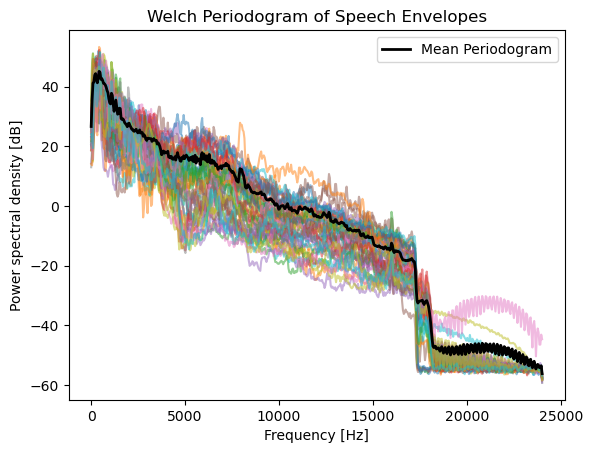

In [113]:
# Plotting setup
fig, ax = plt.subplots()

for Pxx in periodograms:
    ax.plot(frequencies, 10 * np.log10(Pxx), alpha=0.5)
ax.plot(frequencies, 10 * np.log10(mean_periodogram), color='black', linewidth=2, label='Mean Periodogram')
ax.legend()

# Finalize and show the plot
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Power spectral density [dB]')
ax.set_title('Welch Periodogram of Speech Envelopes')
plt.show()


## Estimate the average periodogram during speech segments

For each audio segment, we compute the periodogram using Welch's method. The average periodogram is then calculated by averaging the individual periodograms across all segments. This average periodogram can be used to generate noise that matches the spectral characteristics of the speech segments.


In [114]:
min_duration = np.min(df['ClipEnd'] - df['ClipStart'])

In [115]:
# Directory containing MP4 files
directory = os.path.join(work_path, audio_dir)

# List to store FFT results
fft_results = []
fs = None

# Process each MP4 file in the directory
for index, row in df.iterrows():
    base_filename = row['Filename']
    full_filename = find_mp4_path(base_filename)
    if full_filename is not None:
        samples, fs = extract_audio(full_filename)
        samples = conform_audio_length(samples, fs, min_duration, start_time = row['AudStart'])
        fft_result = compute_fft(samples)
        fft_results.append(fft_result)

# Average the FFT results
avg_fft = np.mean(fft_results, axis=0)

# Generate audio signal from average FFT
avg_samples = np.real(ifft(avg_fft))

# Ensure the audio is within the INT16 valid range
avg_samples = np.int16(avg_samples / np.max(np.abs(avg_samples)) * 32767)

# Convert to audio segment
avg_audio = AudioSegment(
    avg_samples.tobytes(),
    frame_rate = fs,
    sample_width = avg_samples.dtype.itemsize,
    channels = 1
)

if not dry_run:
    # Export the audio to MP4 file
    output_path = os.path.join(work_path, 'average_fft_audio.mp4')
    avg_audio.export(output_path, format="mp4")
    print(f"Generated audio saved to {output_path}")


avg_audio

This sounds like lots of people talking at the same time. We cannot blend this with speech, or the subject will not be able to tell which speaker they should focus on. 

## Create noise from the average periodogram



### Generate noise with the same spectral characteristics as the average periodogram

The goal is to generate noise that has the same spectral characteristics as the average periodogram computed from the speech segments. This can be achieved by using the inverse Fourier transform of the average periodogram to create a time-domain noise signal.

Strictly speaking, this is not pink noise because the pink noise has larger lower frequency components, and the power should be -3dB when frequency doubles. However, there was one weird property if we blend in such noise: there could be sudden jumps in noise level when played back on certain devices. 

#### Reason for the sudden jumps in noise level

Some speakers have AGC/loudness normalization. If the playback chain (a smart speaker, TV "auto volume," phone media enhancer) applies dynamic gain, then a stimulus that is noise-only during silences and noise+speech during speech has a fluctuating total level. The device boosts gain during the quiet noise-only stretches and pulls it down when speech arrives, so the noise audibly "pumps" or "breathes." 

#### Why this happens: the AGC mechanism
 
An AGC or loudness normalizer is a feedback loop: it measures the level of the incoming audio and adjusts a gain to hold that level near a target. The key detail is *how it measures level*. Real detectors do not sum raw broadband power - they compute a **frequency-weighted** power, i.e. they weight the amplitude spectrum before summing, exactly a "weighted sum in frequency space":
 
- **K-weighting** (ITU-R BS.1770 / LUFS, used by streaming platforms, TVs, and smart speakers) applies a high-pass that discards energy below roughly 60–100 Hz plus a ~+4 dB high shelf above ~2 kHz, then integrates power.[^1]
- **A-weighting** (common in simpler consumer AGCs) discounts low frequencies even more aggressively: about −19 dB at 100 Hz and −30 dB at 50 Hz, versus 0 dB at 1 kHz.[^2]
- Some chains use **multiband compression** (independent gain per frequency band) or **speech-gated** measurement that reacts specifically to detected dialogue.[^3]

```mermaid
flowchart LR
    accTitle: AGC Feedback Loop With Weighted Detector
    accDescr: Input audio passes through a variable gain to the output. A side chain applies a frequency weighting such as K or A weighting, integrates power to estimate level, compares it to a target, and adjusts the gain. The weighting stage is why noise spectrum matters.
 
    in["🎵 Input audio<br/>(noise / noise+speech)"] --> gain["🎚️ Variable gain"]
    gain --> out["🔈 Output to listener"]
    gain --> weight["⚖️ Frequency weighting<br/>(K- or A-weighting)"]
    weight --> level["📏 Weighted power<br/>integration"]
    level --> comp["🎯 Compare to<br/>target level"]
    comp --> gain
 
    classDef signal fill:#dbeafe,stroke:#2563eb,stroke-width:2px,color:#1e3a5f
    classDef detector fill:#fef9c3,stroke:#ca8a04,stroke-width:2px,color:#713f12
 
    class in,gain,out signal
    class weight,level,comp detector
```

The gain excursion at each speech onset is set by the step in **detector-measured** (weighted) level between the noise-only and noise+speech segments:
 
$$\text{step (dB)} = 10\log_{10}\!\frac{N_w + S_w}{N_w}$$
 
where `N_w` and `S_w` are the *weighted* powers of noise and speech. Now compare the two noise types at the same nominal broadband SNR of −4 dB:
 
| Noise type | Effect of weighting | Effective weighted SNR | Level step at speech onset | Audible result |
| --- | --- | --- | --- | --- |
| Speech-shaped | Scales speech and noise identically (matched spectra) | ≈ −4 dB (unchanged) | ≈ 1.5 dB | Gain nearly constant; no pumping |
| True pink (1/f) | Much of the noise power sits below a few hundred Hz, where the weighting discards it; speech power (300 Hz–4 kHz) passes | ≈ +2 to +6 dB | ≈ 4–7 dB | Large gain swings; noise "pumps" at every speech onset |
 
So the pumping is not caused by the noise spectrum per se - it is caused by the mixture's **weighted level fluctuating over time**, and a spectrally mismatched noise makes that fluctuation large.
 
#### How the phase-randomization method mitigates it
 
The noise in this pipeline is generated by taking the FFT of the concatenated speech corpus, keeping the magnitude spectrum, replacing all phases with uniform random phases, and inverse-transforming. The result is **speech-shaped noise**: identical long-term spectrum to the stimuli, but unintelligible.
 
This mitigates AGC pumping because any frequency weighting the playback device applies scales the speech and the noise by the *same* factor. Consequences:
 
- The weighted SNR equals the mixed broadband SNR (−4 dB), so the weighted level of the mixture rises only ~1.5 dB when speech starts - almost nothing for the gain loop to react to. The stimulus is effectively *stationary as seen through the detector*.
- Under multiband compression, the noise energy co-occupies the speech bands, so no band sees a large noise-only-to-speech transition; spectral "breathing" is also suppressed.
- As a side benefit, the stated SNR is spectrally honest: masking energy sits exactly where the speech energy is, so −4 dB means roughly −4 dB in every band that matters for intelligibility - unlike pink noise, which under-masks the 1–4 kHz intelligibility region and over-masks the lows.
In the mixing step, $coef_{1}^{2} + coef_{2}^{2} = 1$ additionally holds total power constant across SNR conditions, so different-SNR files present at nearly equal loudness and don't trigger different static normalization gains.
 
 
#### Other mitigation methods
 
The spectral-matching fix minimizes the artifact but does not remove the root cause (dynamic processing in the playback path). Complementary or alternative approaches:
 
| Method | What it does | Notes |
| --- | --- | --- |
| Disable AGC / auto-volume on the playback device | Removes the feedback loop entirely | The standard psychophysics practice: fixed, calibrated gain; verify with a measurement mic that output tracks the file |
| Pre-normalize files to the platform's loudness target (e.g. `ffmpeg loudnorm` to −16 LUFS) | If files already sit at the target, platform normalization applies ~0 dB static gain | Prevents different conditions receiving different static gains[^4] |
 
> **Note:** 
>
> 1. If any dynamic processing remains active in the chain, the SNR at the listener's ear differs from the mixed −4 dB in a time-varying way, a validity problem independent of noise color. Spectral matching reduces the symptom; a calibrated, processing-free playback path removes the cause. 
> 2. In addition, for reproducible and reliable results, we decided not to use the alternative mitigation methods since not all speakers have the same configurations, especially the machine which generates the stimuli files may not have the same configuration as the playback device in our EMU. 
> 3. We sample the stimuli files generated from Pink noises and Speech-shaped noises with the same SNR of -4 dB, with the same playback device and AGC turned off, and the same volume level. The audio intelligibility are similar.



First, let's concaternate all the speech segments together to create a long signal. Then, we can compute the average periodogram of this concatenated signal and generate noise with the same spectral characteristics. This signal should be long enough to avoid padding the noise with zeros.

In [116]:
directory = os.path.join(work_path, audio_dir)

# Concat signals
def get_audios( directory ):
    for filename in os.listdir(directory):
        if filename.endswith(".mp4"):
            file_path = os.path.join(directory, filename)
            samples, _ = extract_audio(file_path)
            yield samples

audios = [x for x in get_audios( directory )]
concated_signals = np.concatenate(audios)

print(f"Concatenated signal length: {len(concated_signals)} samples, sample rate: {sample_rate} Hz, duration: {len(concated_signals)/sample_rate:.2f} seconds")

Concatenated signal length: 9625600 samples, sample rate: 48000 Hz, duration: 200.53 seconds


In [117]:
# Spectrum of the concatenated signal
spec = fft(concated_signals)
N = len(spec)

spectrum = np.abs(spec[:N//2])
freqs = np.fft.fftfreq(N, 1/sample_rate)[:N//2]

phase = np.random.uniform(0, 2 * np.pi, len(spectrum))
phase[0] = 0

newspec = np.concatenate([spectrum * np.exp( phase * 1j), (spectrum * np.exp( -phase * 1j))[:0:-1] ])
noise_wav = normalize_sound(ifft(newspec).real)

generate_audioclip(noise_wav, sample_rate)

Sanity-check: The noise generated from the average periodogram should have a similar spectral shape to the average periodogram itself. We can plot the periodogram of the generated noise and compare it to the average periodogram to verify this. The spectrum might have different energy levels, but the overall shape should be similar.

The power drops significantly near 16,000 Hz, which is likely due to the low-pass filtering applied during the audio processing. This is expected and does not affect the results of the noise generation, as the relevant frequency range for speech intelligibility is typically below this cutoff.

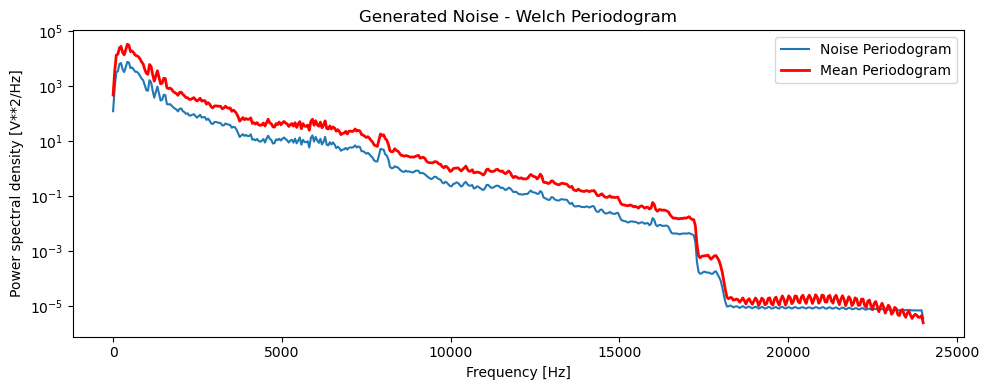

In [118]:
# Plot raw trace of the generated noise & its welch periodogram
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Plot Welch periodogram of the generated noise
f_noise, Pxx_noise = compute_welch_periodogram(noise_wav, sample_rate)
ax.semilogy(f_noise, Pxx_noise, label='Noise Periodogram')
# Add mean_periodogram overlay for comparison
ax.semilogy(frequencies, mean_periodogram, color='red', linewidth=2, label='Mean Periodogram')
ax.legend()

ax.set_title('Generated Noise - Welch Periodogram')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Power spectral density [V**2/Hz]')


plt.tight_layout()


## Blend the generated noise with the speech segments at given SNR levels

In [119]:
noise_wav

array([2350, 1781, 1282, ..., 3384, 3115, 2800],
      shape=(9625599,), dtype=int16)

1. Normalize the audio files to have the same sound level during speech segments.
    ```python
      normalized = normalize_sound(samples, tp_range = tp_range)
    ```
2. Blend the noise with the normalized speech segments at a specified SNR. The SNR can be adjusted to create different levels of noise masking.
3. Return the blended audio for further processing or saving to a file.


In [120]:
def generate_stimuli(row, modality = None, snr = None, dry_run = False):
    base_fileprefix = row['Filename']
    full_filename = find_mp4_path(base_fileprefix, modality = modality)
    if full_filename is None:
        return None
    base_filename = os.path.basename(full_filename)
    samples, fs = extract_audio(full_filename)
    tp_range=[ row['AudStart'] * fs, row['AudEnd'] * fs ]
    # Normalize the original audio file so the sound level is the same during 
    # speech segments
    normalized = normalize_sound(samples, tp_range = tp_range)
    len_samples = len(normalized)
    if snr is None or snr == 0:
        save_dirname = 'normalized_file'
        new_fname = base_filename
        mixed = normalized
    else:
        save_dirname = f'noisy_{snr}dB'
        new_fname = base_filename.replace('.mp4', f'_{snr}dB.mp4')
        wav1 = normalized.astype(np.float32)
        start_idx = np.random.randint(0, len(noise_wav) - len_samples)
        wav2 = noise_wav[start_idx: start_idx + len_samples].astype(np.float32)
        # snr = -4dB, then 20log10(signal / noise) = -4
        # signal / noise = np.power(10, snr / 20)
        # noise = sqrt(1- signal^2)
        # signal^2 = 1 - 1 / ( np.power(10, snr / 10) + 1 )
        coef1 = np.sqrt( 1. - 1. / ( np.power(10., snr / 10.) + 1. ) )
        coef2 = np.sqrt( 1. - coef1 * coef1)
        mixed = wav1 * coef1 + wav2 * coef2
        mixed = mixed.astype(np.int16)
        if verbose or dry_run:
            print(f"Mixing {base_filename} with noise at SNR {snr} dB: coef1={coef1:.4f}, coef2={coef2:.4f}. Original sound level: {get_sound_level(normalized, tp_range = tp_range):.2f}, Mixed sound level: {get_sound_level(mixed, tp_range = tp_range):.2f}")
    audio_segment = AudioSegment(
        mixed.tobytes(),
        frame_rate=fs,
        sample_width=mixed.dtype.itemsize,
        channels=1
    )
    if not dry_run:
        save_dirpath = os.path.join(work_path, save_dirname)
        if not os.path.exists( save_dirpath ):
            os.mkdir(save_dirpath)
        # audio_segment.export(out_f=os.path.join(save_dirpath, new_fname), format="mp4")
        # Add back videos from full_filename
        mux_audio_with_video(full_filename, audio_segment, os.path.join(save_dirpath, new_fname))
    return audio_segment



#### Test flight

In [121]:
generate_stimuli({'Filename' : "BOOTH_DANIELLE", 'AudStart': 0.795, 'AudEnd':1.28}, snr = 0, dry_run = True)

In [122]:
generate_stimuli({'Filename' : "BOOTH_DANIELLE", 'AudStart': 0.795, 'AudEnd':1.28}, snr = -3, dry_run = True)

Mixing BOOTH_DANIELLE.mp4 with noise at SNR -3 dB: coef1=0.5778, coef2=0.8162. Original sound level: 2047.70, Mixed sound level: 2008.32


In [123]:
generate_stimuli({'Filename' : "BOOTH_DANIELLE", 'AudStart': 0.795, 'AudEnd':1.28}, snr = -6, dry_run = True)

Mixing BOOTH_DANIELLE.mp4 with noise at SNR -6 dB: coef1=0.4481, coef2=0.8940. Original sound level: 2047.70, Mixed sound level: 2104.15


In [124]:
generate_stimuli({'Filename' : "BOOTH_DANIELLE", 'AudStart': 0.795, 'AudEnd':1.28}, snr = -12, dry_run = True)

Mixing BOOTH_DANIELLE.mp4 with noise at SNR -12 dB: coef1=0.2436, coef2=0.9699. Original sound level: 2047.70, Mixed sound level: 1985.17


In [ ]:
# def generate_stimuli(row, modality = None, snr = None, dry_run = False):

# Creating video
print("Blending step 1...")
df.apply(generate_stimuli, axis=1, snr=0, modality = "v", dry_run = False)
print("Blending step 2...")
df.apply(generate_stimuli, axis=1, snr=0, modality = "a", dry_run = False)
print("Blending step 3...")
df.apply(generate_stimuli, axis=1, snr=-4, modality = "v", dry_run = False)
print("Blending step 4...")
df.apply(generate_stimuli, axis=1, snr=-4, modality = "a", dry_run = False)
print("Done normalizing the speech amplitude and blending all stimuli files with noise at -4 dB SNR.")

Blending step 1...
Blending step 2...
Blending step 3...
Blending step 4...
Done normalizing the speech amplitude and blending all stimuli files with noise at -4 dB SNR.
